# Surrogate Modeling for Sensitivity Analysus
## AUC Prediction for Polarization Curve Regions

In this script, I drop the use of current density (`ifc`) as an input and instead predict integrated voltage (AUC) for distinct physical regions of the polarization curve. The idea is to compute the area under the curve for three segments: Activation, Ohmic, and Mass Transport.

Each XGBoost model will predict the AUC of one region using only the 13 input parameters. This setup is more interpretable and aligns with the underlying electrochemical processes.

## Region definitions

The polarization curve is split into three regions, based on current density:


In [14]:
REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

In [24]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

import sys
import os
import pandas as pd
sys.path.append("../external/AlphaPEM")

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves

### Compute AUC for a Region

For each configuration, I compute a discrete integral (using trapezoidal rule) of the voltage values over the selected current range.

In [16]:
def compute_region_auc(row, ifc_cols, ucell_cols, region_bounds):
    ifcs = row[ifc_cols].values
    volts = row[ucell_cols].values
    mask = (ifcs >= region_bounds[0]) & (ifcs < region_bounds[1])
    return np.trapezoid(volts[mask], ifcs[mask]) if np.any(mask) else np.nan

### Nested Cross-Validation for One Region

The function below performs nested cross-validation for a selected region. It computes the AUC per configuration, trains an XGBoost model using only the input parameters (no ifc), and evaluates performance using outer CV.

In [27]:
valid_data.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification,config_id,AUC_ohmic
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.710685,0.701266,0.691858,0.682437,0.672987,0.663492,0.653933,valid,0,0.925458
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.699520,0.691411,0.682963,0.674201,0.665215,0.656067,0.646718,valid,1,0.888930
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.672719,0.664526,0.658328,0.651771,0.644673,0.636798,0.628506,valid,2,0.864168
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.696881,0.686989,0.677044,0.667028,0.656922,0.646707,0.636362,valid,3,0.932929
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.710475,0.701074,0.691673,0.682255,0.672806,0.663305,0.653740,valid,4,0.927037


In [19]:
def train_auc_model_for_region(valid_data, region_name, input_cols):
    assert region_name in REGIONS, f"Unknown region: {region_name}"
    region_bounds = REGIONS[region_name]
    print(f"[INFO] Starting nested CV for region: '{region_name}' in range {region_bounds}")

    # Identify relevant columns
    ifc_cols = [col for col in valid_data.columns if col.startswith("ifc_")]
    ucell_cols = [col for col in valid_data.columns if col.startswith("Ucell_")]
    print(f"[INFO] Identified {len(ifc_cols)} current density columns and {len(ucell_cols)} voltage columns.")

    # Compute region-specific AUC
    target_name = f"AUC_{region_name}"
    print(f"[INFO] Computing AUC target for region: {region_name}")
    valid_data[target_name] = valid_data.apply(
        compute_region_auc, axis=1, args=(ifc_cols, ucell_cols, region_bounds)
    )
    n_before = len(valid_data)
    valid_data = valid_data.dropna(subset=[target_name])
    print(f"[INFO] Dropped {n_before - len(valid_data)} samples with no valid AUC in this region. Remaining: {len(valid_data)}")

    # Split input and output
    X = valid_data[input_cols]
    y = valid_data[target_name]
    groups = valid_data["config_id"]
    print(f"[INFO] Input shape: {X.shape}. Target shape: {y.shape}")

    # Hyperparameter grid
    model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        "n_estimators": [300, 500],
        "max_depth": [6, 8],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }
    print(f"[INFO] Defined hyperparameter grid with {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['subsample']) * len(param_grid['colsample_bytree'])} combinations")

    # Outer CV
    outer_cv = GroupKFold(n_splits=5)
    scores = {"mae": [], "r2": [], "rmse": []}

    for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):
        print(f"\n[INFO] Starting outer fold {i+1}/5")
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

        inner_cv = GroupKFold(n_splits=3)
        print("[INFO] Performing inner grid search (3-fold CV)...")
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=inner_cv.split(X_train, y_train, groups.iloc[train_idx]),
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"[INFO] Best hyperparameters for fold {i+1}: {grid.best_params_}")

        y_pred = best_model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_true = y_test, y_pred = y_pred)

        scores["mae"].append(mae)
        scores["r2"].append(r2)
        scores["rmse"].append(rmse)

        print(f"[INFO] Fold {i+1} results — MAE={mae:.4f}, R²={r2:.4f}, RMSE={rmse:.4f}")

    print("\n[INFO] Cross-Validation Summary:")
    for metric in scores:
        print(f"  Mean {metric.upper()}: {np.mean(scores[metric]):.4f} ± {np.std(scores[metric]):.4f}")

    print(f"[INFO] Finished nested CV for region: '{region_name}'")
    return best_model, scores

### Beginning

In [9]:
data = pd.read_pickle("../sampling_test/validated_final_df.pkl")
valid_data = data[data["classification"].isin(["valid"])].copy()
print("There are", len(valid_data), "valid polarization curves available.")

valid_data["config_id"] = valid_data.index

ifc_columns = [col for col in data.columns if col.startswith("ifc_")]
ucell_columns = [col for col in data.columns if col.startswith("Ucell_")]

INPUT_COLUMNS = [
    'Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau',
    'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c'
]

There are 27708 valid polarization curves available.


In [13]:
REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

In [20]:
model_ohmic, metrics_ohmic = train_auc_model_for_region(
    valid_data, region_name="ohmic", input_cols=INPUT_COLUMNS
)

[INFO] Starting nested CV for region: 'ohmic' in range (0.4, 1.6)
[INFO] Identified 31 current density columns and 31 voltage columns.
[INFO] Computing AUC target for region: ohmic
[INFO] Dropped 0 samples with no valid AUC in this region. Remaining: 27708
[INFO] Input shape: (27708, 13). Target shape: (27708,)
[INFO] Defined hyperparameter grid with 32 combinations

[INFO] Starting outer fold 1/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 1: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}
[INFO] Fold 1 results — MAE=0.0621, R²=0.6693, RMSE=0.0277

[INFO] Starting outer fold 2/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 2: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}
[INFO] Fold 2 results — MAE=0.0611, R²=0.6672, RMSE=0.0292

[INFO] Starting outer fold 3/5
[INFO] Performing inner gri

In [28]:
import shap
import pandas as pd
import numpy as np

def compute_shap_importance(model, df, region_name, input_cols, sample_frac=1.0, random_state=42, verbose=True):
    """
    Computes SHAP feature importance for a trained XGBoost model on AUC prediction.

    Parameters
    ----------
    model : xgboost.XGBRegressor
        Trained model.
    df : pd.DataFrame
        Full validated dataset, must include config_id and AUC_<region_name> column.
    region_name : str
        Name of the region (e.g., "activation", "ohmic", "mass_transport").
    input_cols : list
        List of input feature names (13 features).
    sample_frac : float, optional
        Fraction of data to sample for SHAP computation (default 1.0).
    random_state : int, optional
        Random seed for reproducibility.
    verbose : bool, optional
        Whether to print progress info.

    Returns
    -------
    pd.DataFrame
        SHAP feature importance ranking with columns ['feature', 'mean_abs_shap'].
    """
    target_col = f"AUC_{region_name}"

    if target_col not in df.columns:
        raise ValueError(f"[ERROR] Column '{target_col}' not found in the dataframe.")

    # Filter rows with non-NaN AUC
    df_region = df.dropna(subset=[target_col]).copy()
    X_full = df_region[input_cols]

    if sample_frac < 1.0:
        X_sample = X_full.sample(frac=sample_frac, random_state=random_state)
        if verbose:
            print(f"[INFO] Using a sample of {len(X_sample)} rows from {len(X_full)} total rows for SHAP.")
    else:
        X_sample = X_full
        if verbose:
            print(f"[INFO] Using full dataset ({len(X_sample)} rows) for SHAP.")

    if verbose:
        print("[INFO] Creating SHAP TreeExplainer...")
    explainer = shap.Explainer(model)

    if verbose:
        print("[INFO] Computing SHAP values...")
    shap_values = explainer(X_sample)

    if verbose:
        print("[INFO] Aggregating mean absolute SHAP values per feature...")
    mean_abs_shap = pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
    }).sort_values(by="mean_abs_shap", ascending=False)

    return mean_abs_shap


In [29]:
shap_df_ohmic = compute_shap_importance(
    model=model_ohmic,
    df=valid_data,
    region_name="ohmic",
    input_cols=INPUT_COLUMNS,
    sample_frac=0.3
)

[INFO] Using a sample of 8312 rows from 27708 total rows for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...


In [30]:
print(shap_df_ohmic.head(10))

       feature  mean_abs_shap
5          tau       0.061412
10    i0_c_ref       0.054427
1       Pa_des       0.042165
0          Tfc       0.041157
6   epsilon_mc       0.032506
12     kappa_c       0.031917
9           Re       0.018991
3    Phi_c_des       0.014476
11    kappa_co       0.011179
2           Sc       0.009776


In [31]:
import matplotlib.pyplot as plt

def plot_shap_bar(shap_df, top_n=13):
    plt.figure(figsize=(8, 5))
    plt.barh(shap_df["feature"][:top_n][::-1], shap_df["mean_abs_shap"][:top_n][::-1])
    plt.xlabel("Mean(|SHAP value|)")
    plt.title("SHAP Feature Importance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

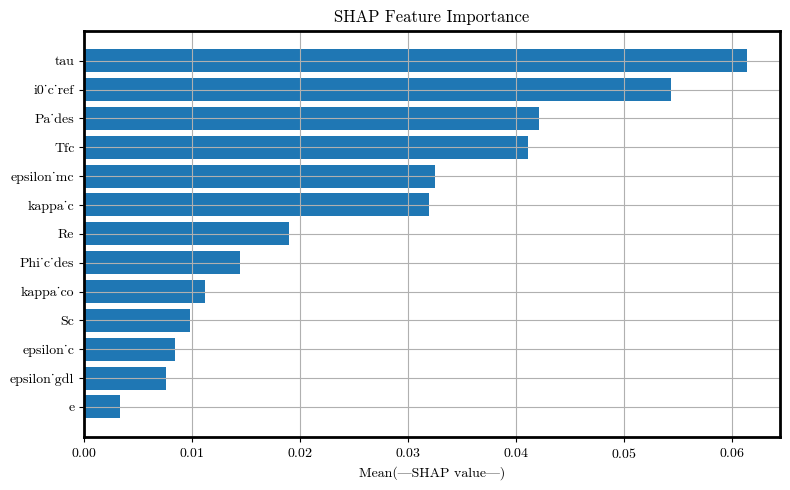

In [32]:
plot_shap_bar(shap_df_ohmic)